# Business Insights & Recommendations
## Indian Food Delivery App Sentiment Intelligence System

---
This notebook translates sentiment analysis results into actionable 
business insights and recommendations for Zomato, Swiggy and Blinkit.

**Key Question:** What specific improvements should each app prioritize
to increase customer satisfaction?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading

Loading preprocessed reviews dataset for business analysis.

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Data_Science_Project\05_NLP_Sentiments_Project\Data\Processed\processed_reviews.csv")

print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (1459, 9)


## 2. App-wise Sentiment & Satisfaction Analysis

Comparing customer sentiment and average ratings across all three apps
to identify which app performs best and which needs most improvement.

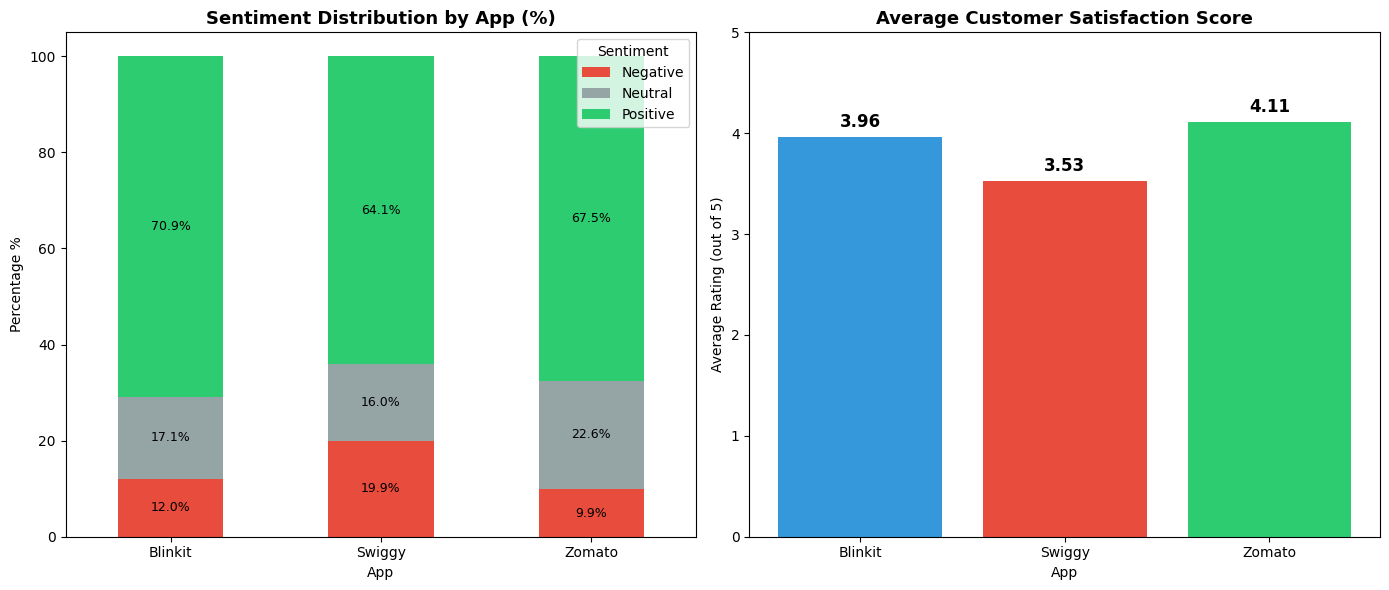

Business Insight 1 saved!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

app_sentiment = df.groupby(['app', 'sentiment']).size().unstack()
app_sentiment_pct = app_sentiment.div(
    app_sentiment.sum(axis=1), axis=0) * 100

app_sentiment_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=['#e74c3c', '#95a5a6', '#2ecc71']
)
axes[0].set_title('Sentiment Distribution by App (%)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('App')
axes[0].set_ylabel('Percentage %')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')

for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', 
                       label_type='center', fontsize=9)

satisfaction = df.groupby('app')['rating'].mean().round(2)
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[1].bar(satisfaction.index, 
                    satisfaction.values, color=colors)
axes[1].set_title('Average Customer Satisfaction Score',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('App')
axes[1].set_ylabel('Average Rating (out of 5)')
axes[1].set_ylim(0, 5)

for bar, val in zip(bars, satisfaction.values):
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.1,
                 f'{val}', ha='center', 
                 fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/business_insight_1.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Business Insight 1 saved!")

## 3. Rating Trend Analysis

Analyzing how customer ratings have changed over time for each app
to identify improving or declining trends.

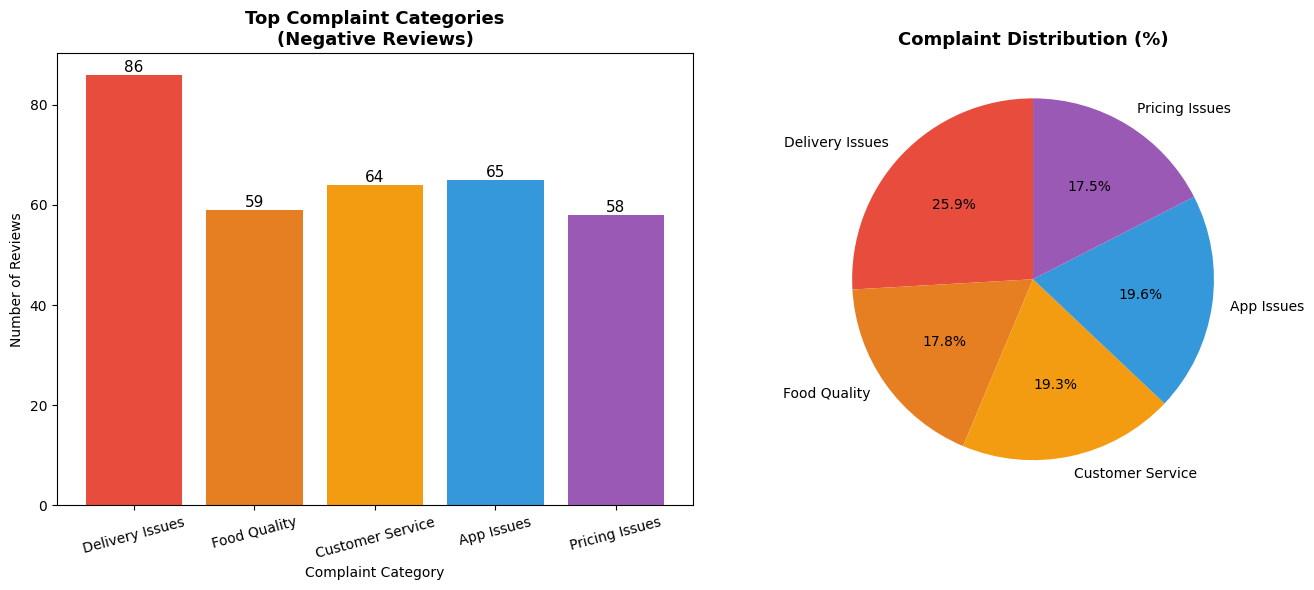

Business Insight 2 saved!


In [4]:
from collections import Counter

complaint_keywords = {
    'Delivery Issues'  : ['delivery', 'late', 'delay', 
                          'slow', 'time', 'hour'],
    'Food Quality'     : ['cold', 'stale', 'quality', 
                          'taste', 'fresh', 'bad'],
    'Customer Service' : ['support', 'service', 'response',
                          'help', 'agent', 'executive'],
    'App Issues'       : ['app', 'crash', 'bug', 'slow',
                          'update', 'error'],
    'Pricing Issues'   : ['expensive', 'price', 'charge',
                          'money', 'refund', 'costly']
}

negative_reviews = df[df['sentiment'] == 'Negative']['processed_review']

complaint_counts = {}
for category, keywords in complaint_keywords.items():
    count = 0
    for review in negative_reviews:
        if any(keyword in str(review).lower() 
               for keyword in keywords):
            count += 1
    complaint_counts[category] = count

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

categories = list(complaint_counts.keys())
counts = list(complaint_counts.values())
colors = ['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#9b59b6']

bars = axes[0].bar(categories, counts, color=colors)
axes[0].set_title('Top Complaint Categories\n(Negative Reviews)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Complaint Category')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=15)

for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.5,
                 str(count), ha='center', fontsize=11)

axes[1].pie(counts, labels=categories,
            autopct='%1.1f%%', colors=colors,
            startangle=90)
axes[1].set_title('Complaint Distribution (%)',
                   fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/business_insight_2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Business Insight 2 saved!")

## 4. Complaint Category Analysis

Categorizing negative reviews into specific complaint types to identify
the most critical areas requiring immediate business attention.

In [5]:
recommendations = {
    'Priority': [1, 2, 3, 4, 5],
    'Issue': [
        'Delivery Speed & Reliability',
        'App Performance & UI',
        'Customer Service Response',
        'Food Quality Control',
        'Pricing Transparency'
    ],
    'Affected App': [
        'Swiggy (Most)',
        'All Apps',
        'Swiggy & Blinkit',
        'Zomato & Swiggy',
        'Blinkit (Most)'
    ],
    'Complaint %': [
        '25.9%', '19.6%', '19.3%', '17.8%', '17.5%'
    ],
    'Recommendation': [
        'Optimize delivery routes, hire more delivery partners',
        'Fix app crashes, improve UI/UX design',
        'Implement 24/7 chat support, faster resolution',
        'Stricter restaurant quality checks',
        'Show all charges upfront, no hidden fees'
    ]
}

rec_df = pd.DataFrame(recommendations)

print("=" * 70)
print("         BUSINESS RECOMMENDATIONS")
print("=" * 70)
print(rec_df.to_string(index=False))
print("=" * 70)

         BUSINESS RECOMMENDATIONS
 Priority                        Issue     Affected App Complaint %                                        Recommendation
        1 Delivery Speed & Reliability    Swiggy (Most)       25.9% Optimize delivery routes, hire more delivery partners
        2         App Performance & UI         All Apps       19.6%                 Fix app crashes, improve UI/UX design
        3    Customer Service Response Swiggy & Blinkit       19.3%        Implement 24/7 chat support, faster resolution
        4         Food Quality Control  Zomato & Swiggy       17.8%                    Stricter restaurant quality checks
        5         Pricing Transparency   Blinkit (Most)       17.5%              Show all charges upfront, no hidden fees


## 5. Business Recommendations & Action Plan

Based on sentiment analysis of 1459 real customer reviews,
here are prioritized recommendations for food delivery companies.

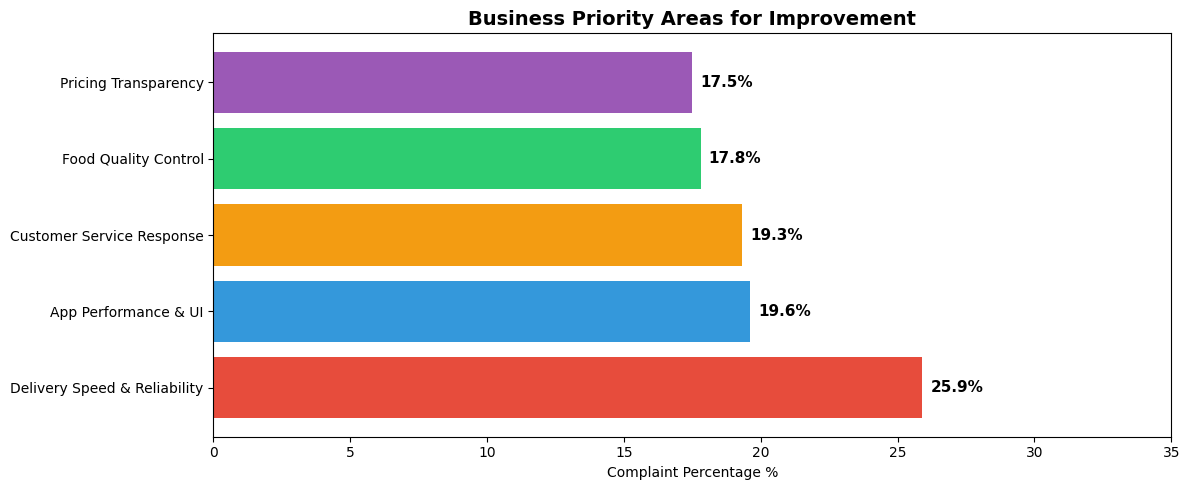

Recommendations saved successfully!


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#e74c3c', '#3498db', '#f39c12', 
          '#2ecc71', '#9b59b6']
bars = ax.barh(
    rec_df['Issue'],
    [25.9, 19.6, 19.3, 17.8, 17.5],
    color=colors
)
for bar, pct in zip(bars, ['25.9%', '19.6%', 
                             '19.3%', '17.8%', '17.5%']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            pct, va='center', fontsize=11,
            fontweight='bold')
ax.set_title('Business Priority Areas for Improvement',
              fontsize=14, fontweight='bold')
ax.set_xlabel('Complaint Percentage %')
ax.set_xlim(0, 35)
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/recommendations.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Recommendations saved successfully!")

## 6. Final Business Summary

### Key Findings:
- **Zomato** leads with highest satisfaction score (4.11/5) and lowest negative sentiment (9.9%)
- **Swiggy** needs urgent attention — highest negative sentiment (19.9%) and lowest rating (3.53/5)
- **Delivery Speed** is the #1 complaint (25.9%) across all apps
- **App Performance** is second biggest issue (19.6%)

### Recommendations by Priority:
| Priority | Issue | Action |
|----------|-------|--------|
| 1 | Delivery Speed | Optimize routes, hire more partners |
| 2 | App Performance | Fix crashes, improve UI/UX |
| 3 | Customer Service | 24/7 support, faster resolution |
| 4 | Food Quality | Stricter restaurant checks |
| 5 | Pricing | Show all charges upfront |

### Business Impact:
> Addressing delivery issues alone can potentially convert 25.9% 
> of negative customers to satisfied ones — directly impacting 
> app ratings and revenue.

---
*Analysis based on 1459 real Google Play Store reviews — March 2026*